# Outspark: grafo histórico de Facebook

Este cuaderno usa el conjunto [WOSN 2009 de MPI-SWS](https://socialnetworks.mpi-sws.org/data-wosn2009.html). La construcción de las amistades como grafo no dirigido se resume en una llamada a `nx.read_edgelist`. Los datos originales se descargan y comprueban con SHA-256.

La BFS para componentes y alcance está implementada en Python en [grafo_facebook.py](https://github.com/outspark-app/outspark-facebook-grafo/blob/main/grafo_facebook.py). Graphviz dibuja directamente los 63 731 nodos y las 817 090 aristas, resaltando en naranja la componente conexa mayor; el mismo archivo genera un subgrafo legible. El cuaderno comprueba que está ejecutando exactamente la versión del archivo con la que se publicó. Las figuras guardadas proceden de una ejecución verificada y pueden regenerarse. Una amistad no demuestra que una publicación haya circulado entre usuarios.


In [ ]:
from pathlib import Path
from urllib.request import urlopen
import hashlib

archivos = {
    "facebook-links.txt.gz": "32d149f76c3421a08b03bfc629a9de6ce65b6fa56272cd9d5424e3de5b1acff2",
    "facebook-wall.txt.gz": "c4449336e346061068b8278d09176b195b3f132f6d6fe50adbc5730938496dca",
}
base = "https://socialnetworks.mpi-sws.org/data/"
for nombre, esperado in archivos.items():
    ruta = Path(nombre)
    if not ruta.is_file() or hashlib.sha256(ruta.read_bytes()).hexdigest() != esperado:
        with urlopen(base + nombre, timeout=120) as origen, ruta.open("wb") as destino:
            while bloque := origen.read(1024 * 1024):
                destino.write(bloque)
    if hashlib.sha256(ruta.read_bytes()).hexdigest() != esperado:
        raise ValueError(f"El archivo {nombre} no coincide con MPI-SWS")
    print(f"Datos verificados: {nombre}")


Datos verificados: facebook-links.txt.gz
Datos verificados: facebook-wall.txt.gz


In [ ]:
import networkx as nx

G = nx.read_edgelist("facebook-links.txt.gz", delimiter="\t", nodetype=int, data=False)
print(f"Grafo: {G.number_of_nodes():,} nodos y {G.number_of_edges():,} aristas")


Grafo: 63,731 nodos y 817,090 aristas


In [ ]:
from urllib.request import urlopen

codigo_url = "https://raw.githubusercontent.com/outspark-app/outspark-facebook-grafo/main/grafo_facebook.py"
with urlopen(codigo_url, timeout=60) as respuesta:
    codigo = respuesta.read()
if hashlib.sha256(codigo).hexdigest() != "760a3a721d0d0bff2760a5528d60c4ad0a1827e88cecac35094c483bbffbb3c0":
    raise ValueError("El código de GitHub cambió; publica una versión nueva del cuaderno")
Path("grafo_facebook.py").write_bytes(codigo)

from grafo_facebook import main
resultado = main(["--links", "facebook-links.txt.gz", "--wall", "facebook-wall.txt.gz", "--out", "salida_facebook"])


{"nodos": 63731, "aristas": 817090, "publicaciones_muro": 876993, "estadisticas": "salida_facebook/estadisticas_facebook.json", "grafo_completo": "salida_facebook/grafo_completo_facebook.png", "subgrafo": "salida_facebook/subgrafo_facebook.png"}


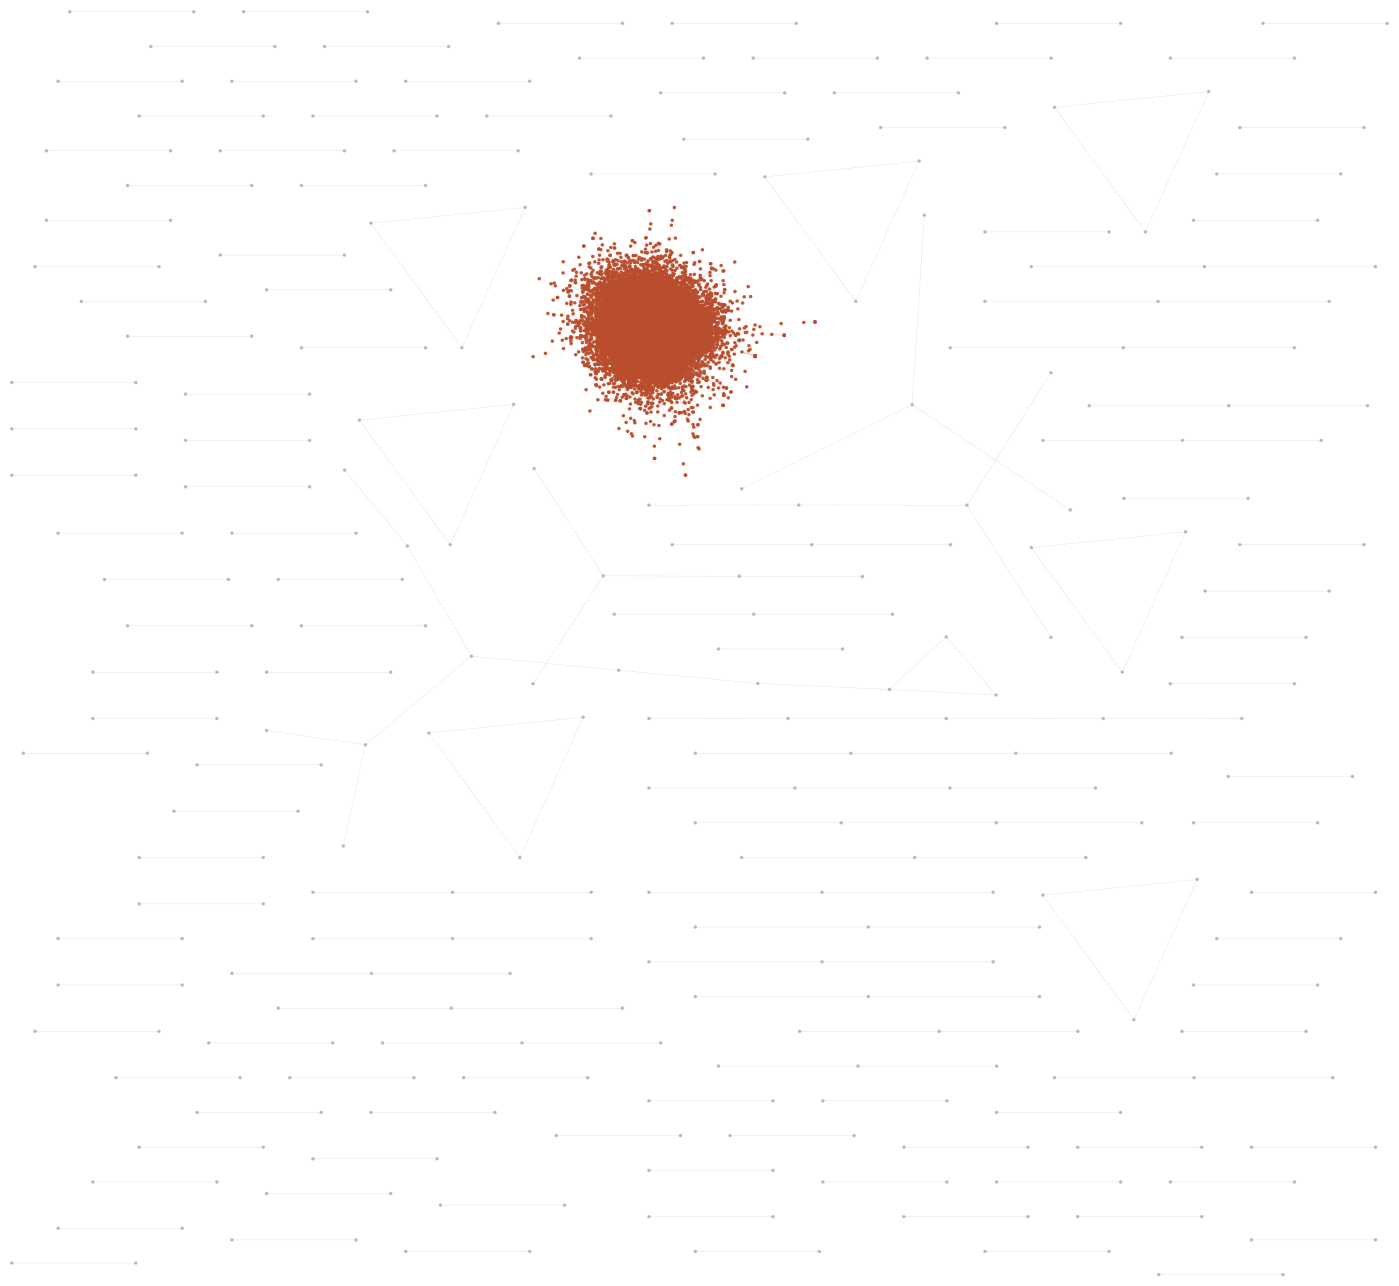

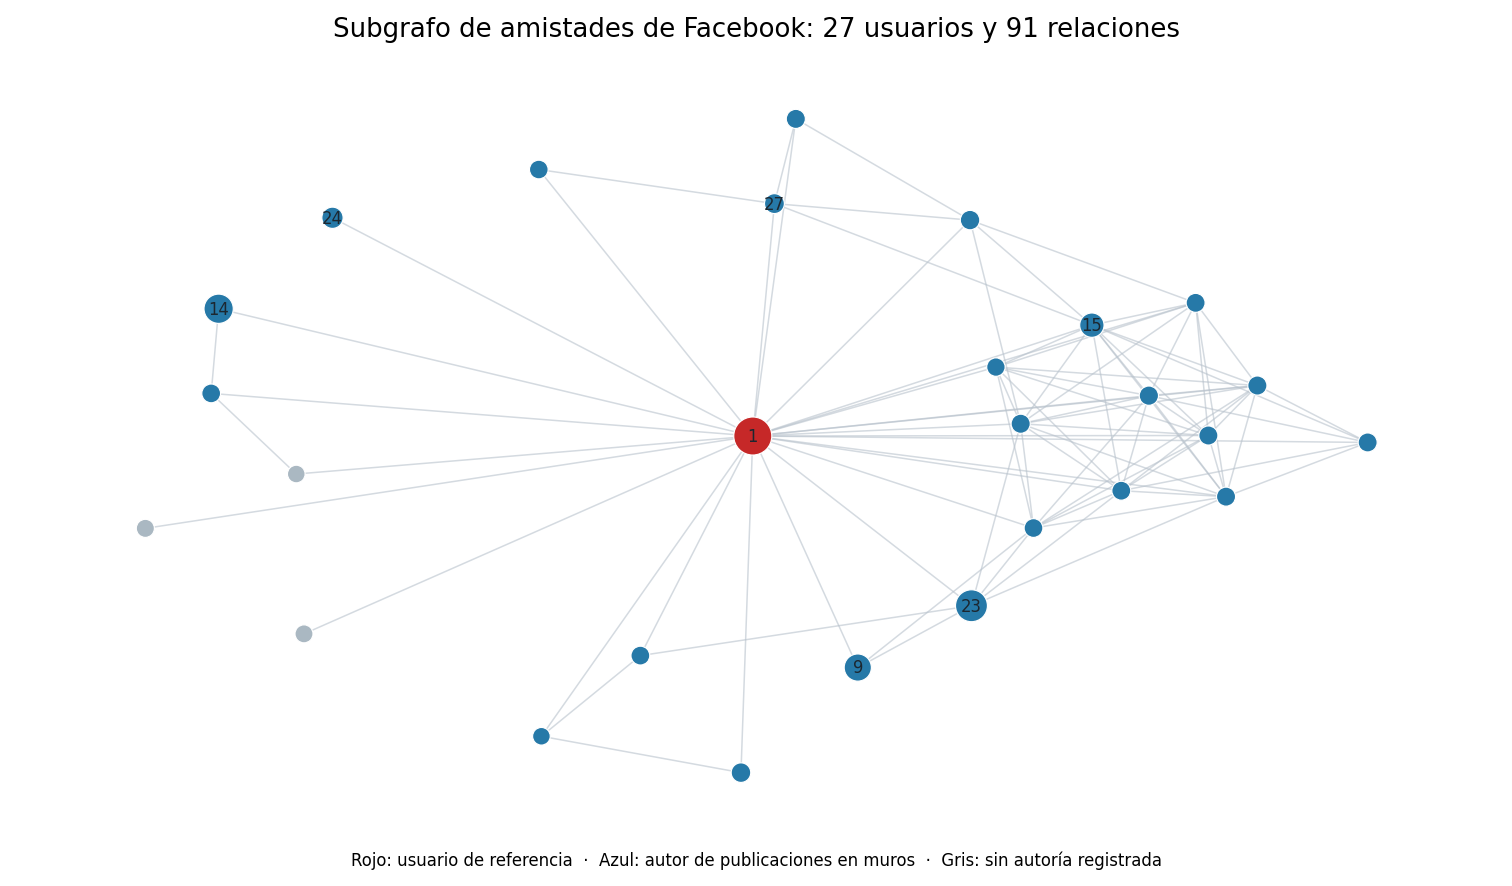

In [ ]:
from IPython.display import Image, display

display(Image(filename="salida_facebook/grafo_completo_facebook.png"))
display(Image(filename="salida_facebook/subgrafo_facebook.png"))
